2025-12-01 10:19:41.723 (   1.250s) [    7F13AA5B4280]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


Generated squid glyph mesh with 66204 points and 98080 polygons scalar values shape: (66204,)


/home/tajo10/miniforge3/envs/uvisbox/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


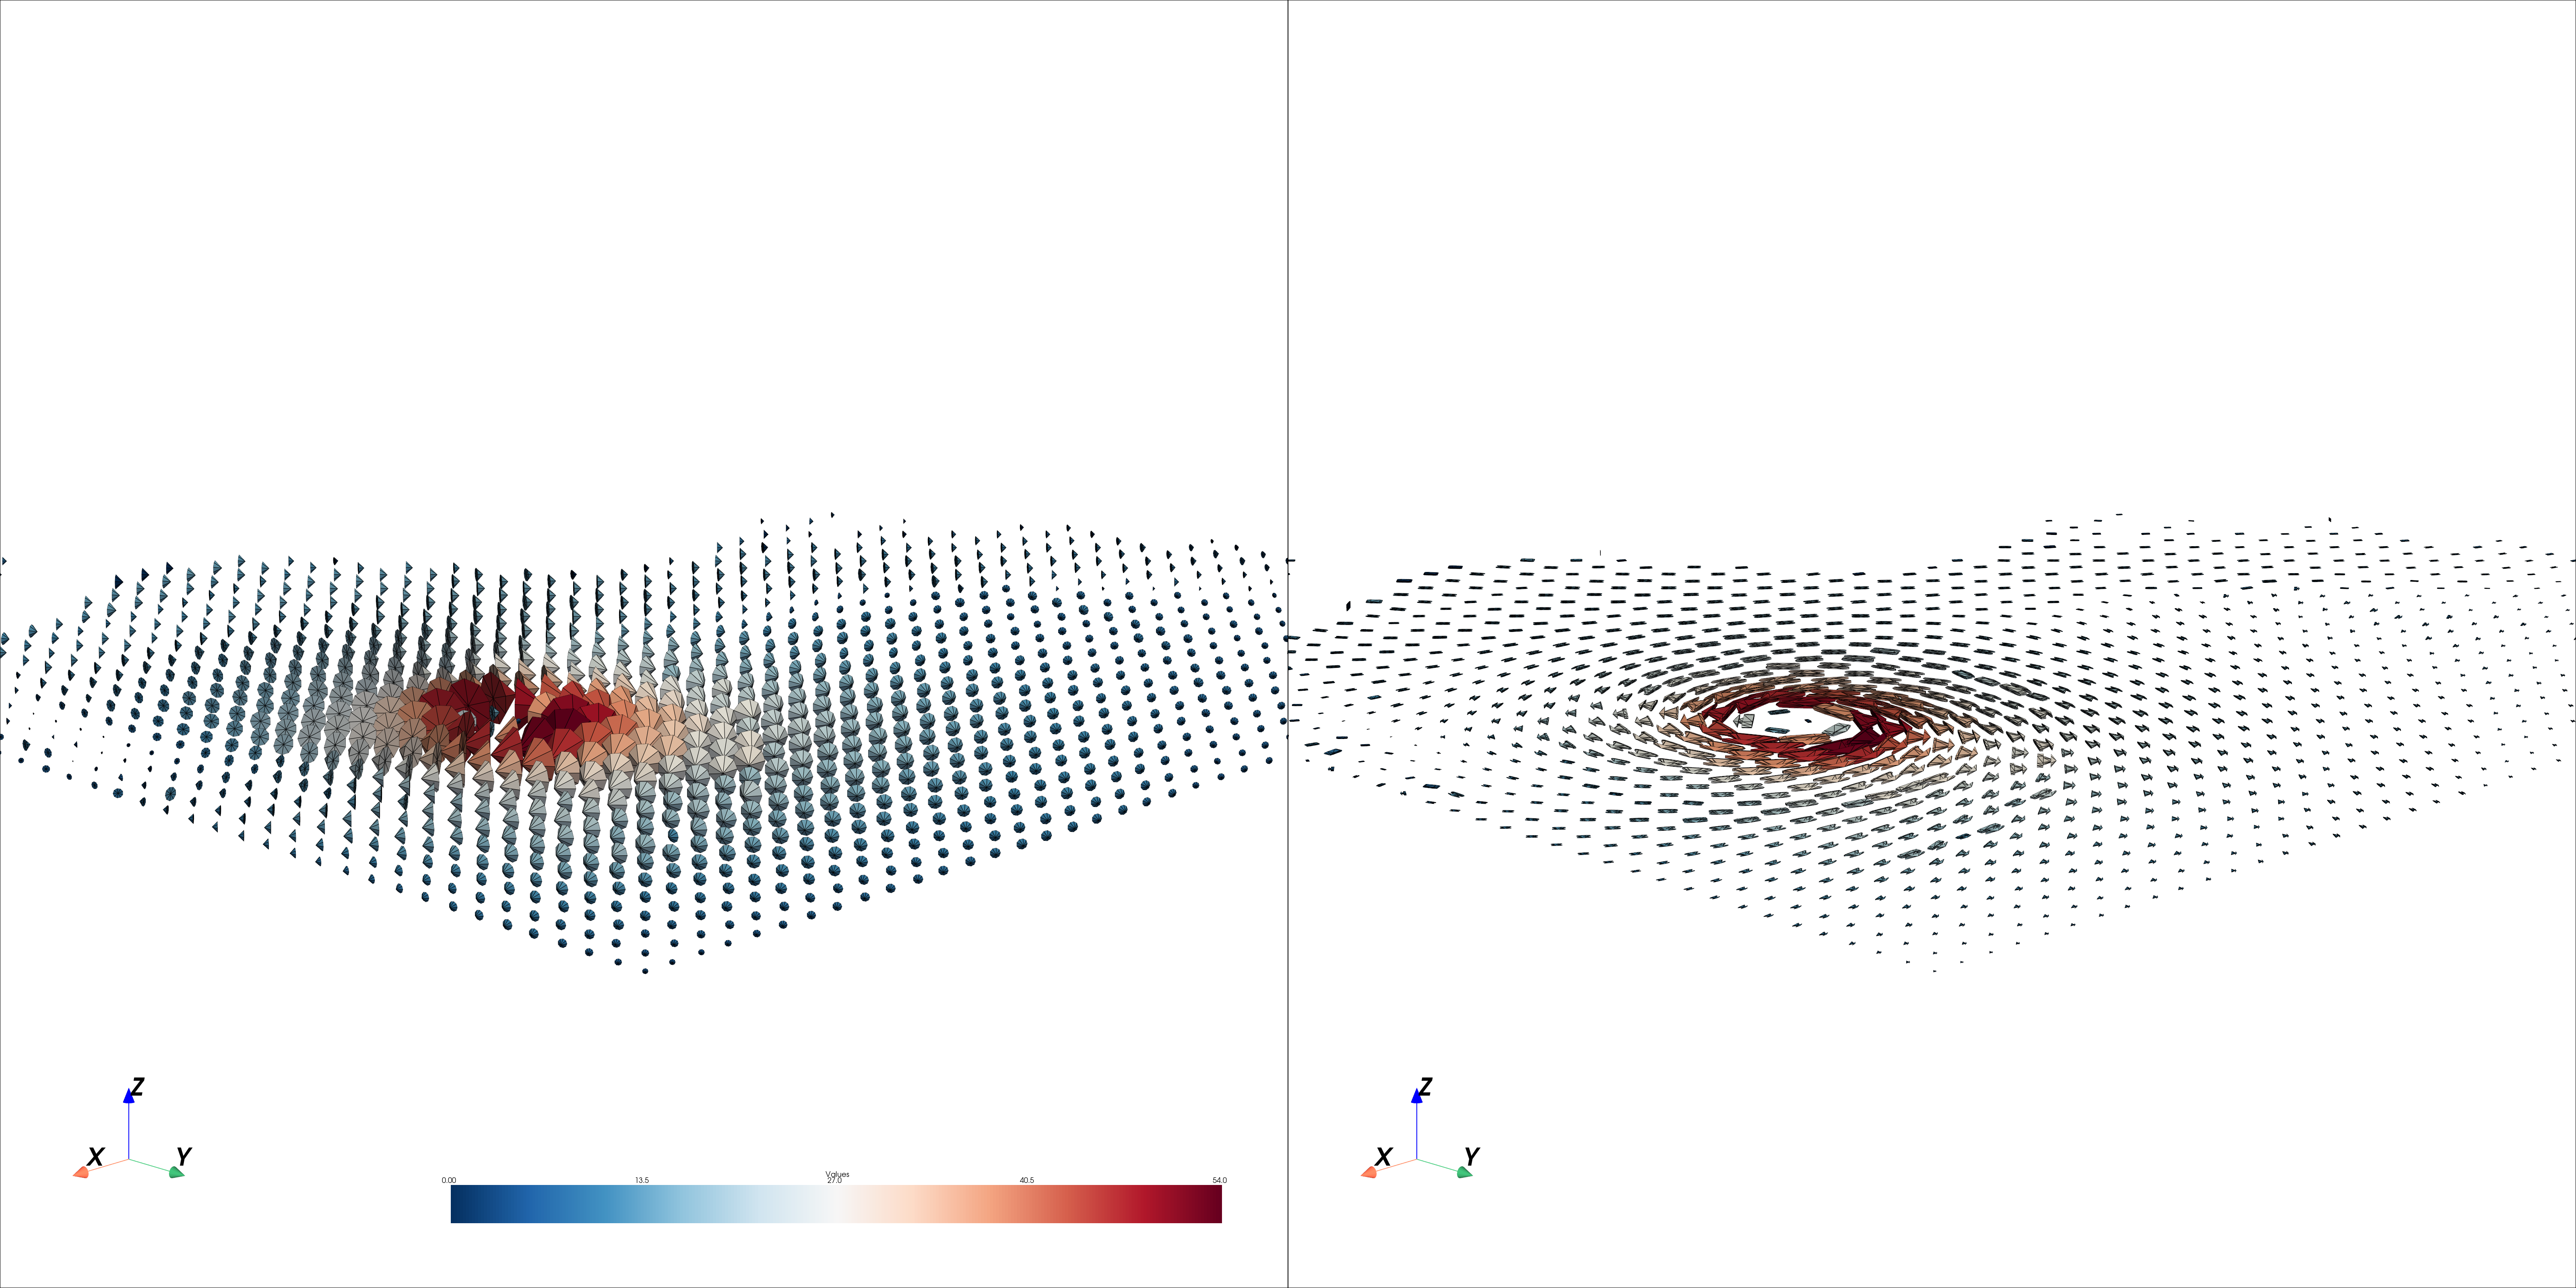

In [ ]:
from vtk.numpy_interface import dataset_adapter as dsa
from uvisbox.Modules.SquidGlyphs import squid_glyph_3D 
from uvisbox.Modules.ConeGlyphs import cone_glyph
import numpy as np
import pyvista as pv

def load_isabel_data():
    data = np.load("../uvisbox/Datasets/hurricane_isabel_ensemble_vectors_time10.npz")
    positions = data['positions']
    vectors = data['vectors']
    magnitudes = np.linalg.norm(vectors, axis=2)
    median_magnitudes = np.median(magnitudes, axis=1)
    return positions, vectors, median_magnitudes

# Load data
positions, ensemble_vectors, median_magnitudes = load_isabel_data()

# Visualization parameters
scaling_factor = 0.2
percenti_value = 95

plotter = pv.Plotter(shape=(1, 2), window_size=[6400, 3200])
plotter.subplot(0, 0)
plotter, points, triangles = cone_glyph(positions, ensemble_vectors, point_values=median_magnitudes, 
                                        percentile=percenti_value, scale=scaling_factor, ax=plotter)

plotter.subplot(0, 1)
plotter, points, triangles = squid_glyph_3D(positions, ensemble_vectors, point_values=median_magnitudes, 
                                            percentile=percenti_value, scale=scaling_factor, ax=plotter)
plotter.link_views()
plotter.show()
# plotter.screenshot("hurricane_isabel_cone_squid_glyphs2.png")


